In [1]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd


# Connessione all'istanza OpenEO
connection = openeo.connect("openeo.dataspace.copernicus.eu")  # esempio, cambia con il tuo endpoint
# Autenticazione
connection.authenticate_oidc()
spatial_extent = {"type":"Polygon","coordinates":[[[14.140778,40.793019],[14.140778,40.915848],[14.348488,40.915848],[14.348488,40.793019],[14.140778,40.793019]]]}


Authenticated using refresh token.


In [6]:
connection.list_collections()

[{'description': 'Sentinel 3 imagery captured by OLCI sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_OLCI_L1B',
  'license': 'proprietary',
  'links': [{'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'type': 'application/schema+json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-olci/items',
    'rel': 'items',
    'type': 'application/geo+json'}],
  'providers': [],
  'stac_extensions': ['https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
   'https://stac-extensions.github.io/eo/v1.0.0/schema.json'],
  'stac_version': '1.0.0',
  'title': 'Sentinel 3 OLCI'},
 {'description': 'Sentinel 3 imagery captured by SLSTR sensor',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2016-04-17T11:33:13Z', None]]}},
  'id': 'SENTINEL3_SLSTR',
  'license': 'proprietary',
  'links': [{'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-slstr',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-slstr/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'type': 'application/schema+json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-3-slstr/items',
    'rel': 'items',
    'type': 'application/geo+json'}],
  'providers': [],
  'stac_extensions': ['https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
   'https://stac-extensions.github.io/eo/v1.0.0/schema.json'],
  'stac_version': '1.0.0',
  'title': 'Sentinel 3 SLSTR'},
 {'description': 'Sentinel 5 Precursor imagery captured by TROPOMI sensor.\n\nThis dataset only supports loading one band at a time.',
  'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]},
   'temporal': {'interval': [['2018-04-30T00:18:50Z', None]]}},
  'id': 'SENTINEL_5P_L2',
  'license': 'proprietary',
  'links': [{'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/',
    'rel': 'root',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-5p-l2',
    'rel': 'self',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections',
    'rel': 'parent',
    'type': 'application/json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-5p-l2/queryables',
    'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
    'type': 'application/schema+json'},
   {'href': 'https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/collections/sentinel-5p-l2/items',
    'rel': 'items',
    'type': 'application/geo+json'}],
  'providers': [],
  'stac_extensions': ['https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
   'https://stac-extensions.github.io/sat/v1.0.0/schema.json',
   'https://docs.sentinel-hub.c

In [26]:
s3cube = connection.load_collection(
    "SENTINEL3_SLSTR_L2_LST",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2023-06-26", "2023-07-01"],  # esempio: mese di luglio 2023
    bands=["LST"]  
)

mean_lst = s3cube.reduce_dimension(dimension="t", reducer="mean")

# Esegue il processo
mean_lst.execute_batch("land_surface_temperature.nc",title="land_surface_temperature")


0:00:00 Job 'j-2507251518574f11a35f12e878450c0e': send 'start'
0:00:13 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:00:18 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:00:25 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:00:33 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:00:42 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:00:55 Job 'j-2507251518574f11a35f12e878450c0e': queued (progress 0%)
0:01:10 Job 'j-2507251518574f11a35f12e878450c0e': running (progress N/A)
0:01:29 Job 'j-2507251518574f11a35f12e878450c0e': running (progress N/A)
0:01:53 Job 'j-2507251518574f11a35f12e878450c0e': running (progress N/A)
0:02:23 Job 'j-2507251518574f11a35f12e878450c0e': finished (progress 100%)


<BatchJob job_id='j-2507251518574f11a35f12e878450c0e'>

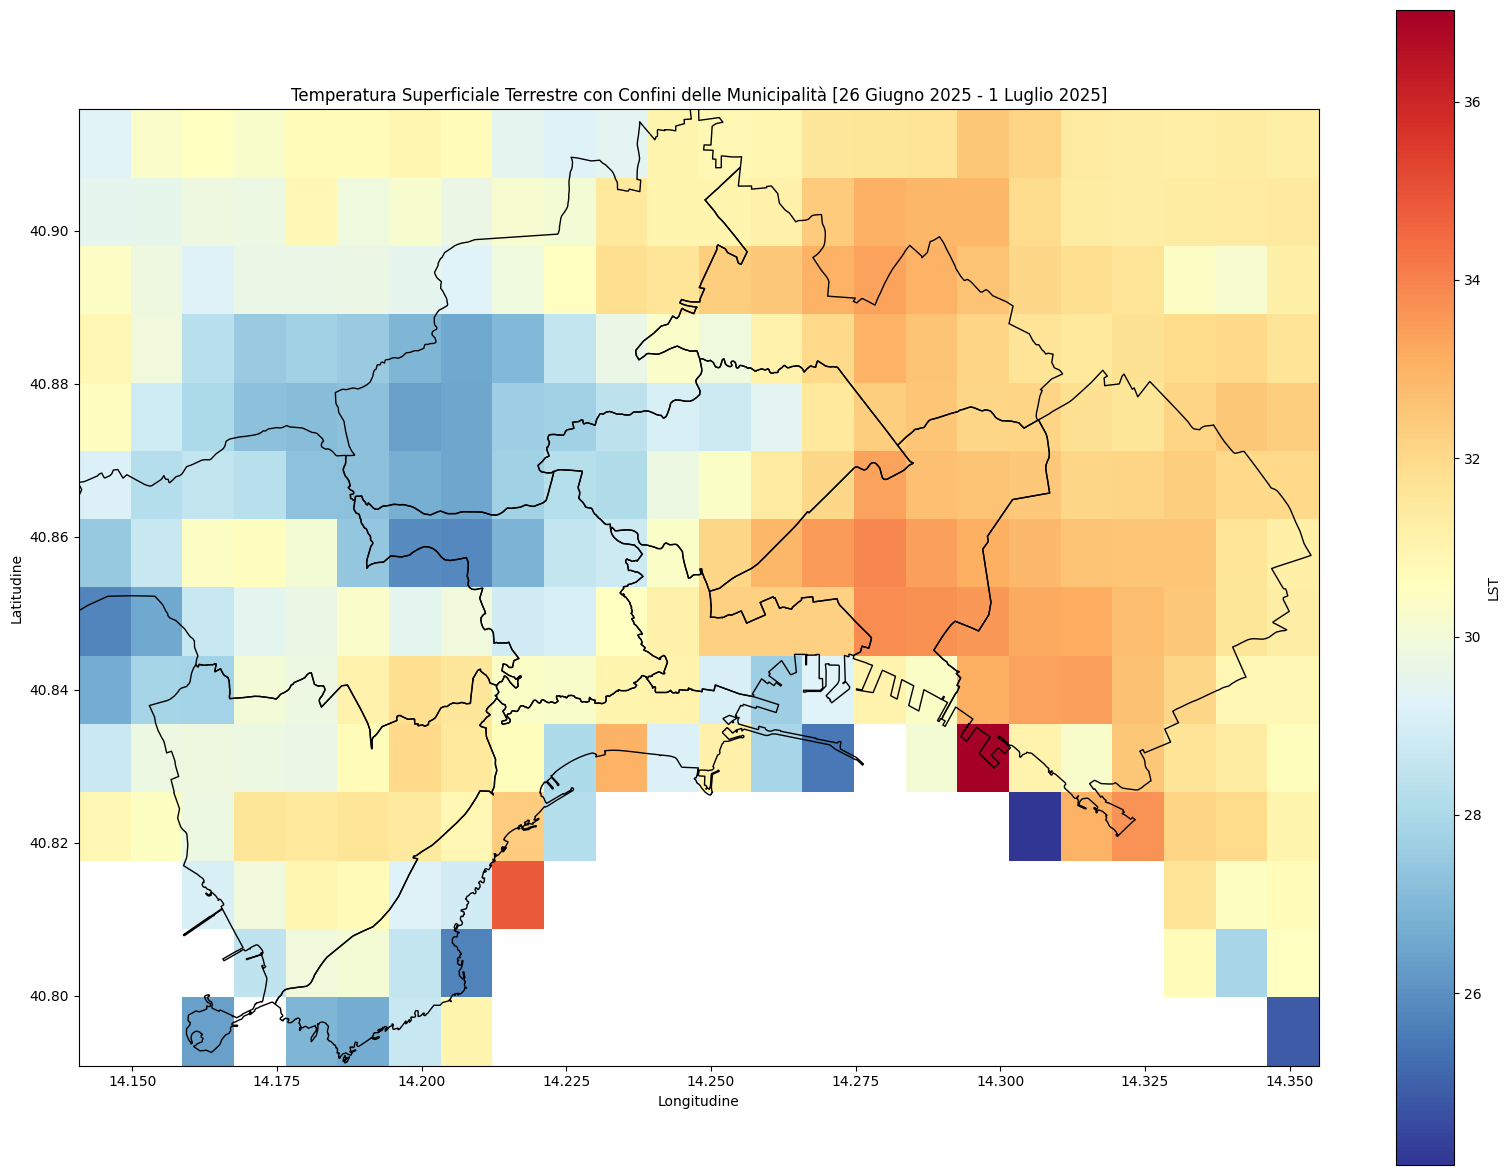

In [3]:

import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd

municipalities = gpd.read_file("municipalita.geojson")  # Carica il GeoDataFrame delle municipalità

# Carica il file NetCDF
ds = xr.open_dataset("land_surface_temperature.nc")
# Visualizza le variabili disponibili

# I gradi della variabili LST sono in Kelvin, quindi convertiamo in Celsius
ds['LST'] = ds['LST'] - 273.15  # Conversione da Kelvin a Celsius   
# Plotta la mappa della temperatura superficiale terrestre e la mappa delle municipalità sovrapposta

fig, ax = plt.subplots(figsize=(20, 15))
ds.LST.plot(ax=ax, cmap='RdYlBu_r')  # oppure cmap='RdYlBu'
municipalities.boundary.plot(ax=ax, color='black', linewidth=1)  # Sovrappone i confini delle municipalità
ax.set_title("Temperatura Superficiale Terrestre con Confini delle Municipalità [26 Giugno 2025 - 1 Luglio 2025]")
ax.set_xlabel("Longitudine")
ax.set_ylabel("Latitudine")
plt.show()
